In [ ]:
# %%
# Notebook: Test HaloBaryonAccretion

# Importações
import numpy as np
import matplotlib.pyplot as plt

from starforge.cosmology.lcdmmodel import LCDMModel
from starforge.cosmology.lcdmperturbation import LcdmPerturbations
from starforge.massfunction.sigma import Sigma
from starforge.massfunction.massfunctions import PressSchechterMF
from starforge.structures.halosbarionicaccretion import HaloBaryonAccretion
from starforge.cosmology.schema import CosmologyParameters


ModuleNotFoundError: No module named 'starforge.cosmology.lcdmbackground'

In [ ]:
# 1. Inicializar parâmetros cosmológicos
params = CosmologyParameters(
    omegam=0.3,
    omegab=0.048,
    omegal=0.7,
    h=0.678,
    sigma8=0.815,
    n_s=0.965,
    deltac=1.686,
    alfa=0.1,
    beta=0.1,
    gama=0.1,
    anorm=1.0,
    ct2=1.0,
    robr0=0.048
)

# Criar background LCDM
cosmo = LcdmBackground(params)


# 2. Inicializar perturbations (growth)
perturb = LcdmPerturbations(cosmo)


# 3. Inicializar Sigma
sigma_calc = Sigma(perturb)

# Criar cache de sigma (pode usar valores pequenos para teste rápido)
sigma_cache = sigma_calc.initialize_sigma_cache(
    zmax=20,
    mass_function_type="PS",
    lmin=6.0,
    lmax=18.0
    )


massfucntion = PressSchechterMF(cosmology=cosmo, sigma=sigma_calc)


# 4. Inicializar HaloBaryonAccretion
halo_accretion = HaloBaryonAccretion(
    cosmology=cosmo,
    massfunction=massfucntion,
    zmax=20.0,

)


In [ ]:
# 5. Calcular baryonic accretion rate
halo_accretion.start_baryonic_accretion_rate()

In [ ]:
# 6. Teste de funções

# Exemplo: halo mass function em z=0
lm_test = 12.0
z_test = 0.0
mf_value = halo_accretion.massfunction.massFunction(lm_test, z_test)
print(f"Mass function (lm={lm_test}, z={z_test}): {mf_value:.3e}")

# Exemplo: número total de halos
n_halos = halo_accretion.halos_n(z_test)
print(f"Total halo mass per comoving volume at z={z_test}: {n_halos:.3e}")

# Exemplo: fração de baryons em estruturas
fb = halo_accretion.fbstruc(z_test)
print(f"Fraction of baryons in structures at z={z_test}: {fb:.3e}")

# Exemplo: baryonic accretion rate
a_test = 1.0 / (1.0 + z_test)
abt_value = halo_accretion.abt(a_test)
print(f"Baryonic accretion rate at a={a_test:.3f}: {abt_value:.3e}")

/home/eduardo/Projects/startforge/src/starforge/sfr/halsobarionicaccretion.py:57: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, err = quad(fmassM, self.__lmInf, self.__lmSup, epsrel=1e-5)


Mass function (lm=12.0, z=0.0): 6.198e-15
Total halo mass per comoving volume at z=0.0: 1.309e+02
Fraction of baryons in structures at z=0.0: 3.439e-09
Baryonic accretion rate at a=1.000: 1.134e-09


In [ ]:
z_vals = np.linspace(0, 20, 100)
fb = [halo_accretion.fbstruc(z) for z in z_vals]

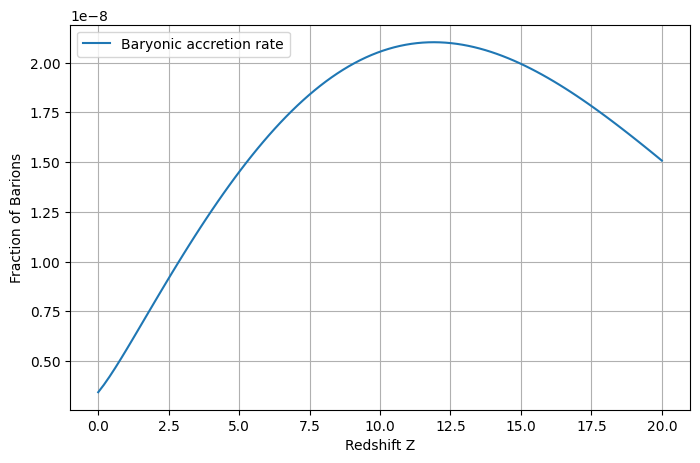

In [ ]:
# 7. Plot de baryonic accretion vs scale factor
plt.figure(figsize=(8,5))
plt.plot(z_vals, fb, label="Baryonic accretion rate")
plt.xlabel("Redshift Z")
plt.ylabel("Fraction of Barions")
plt.legend()
plt.grid(True)
plt.show()

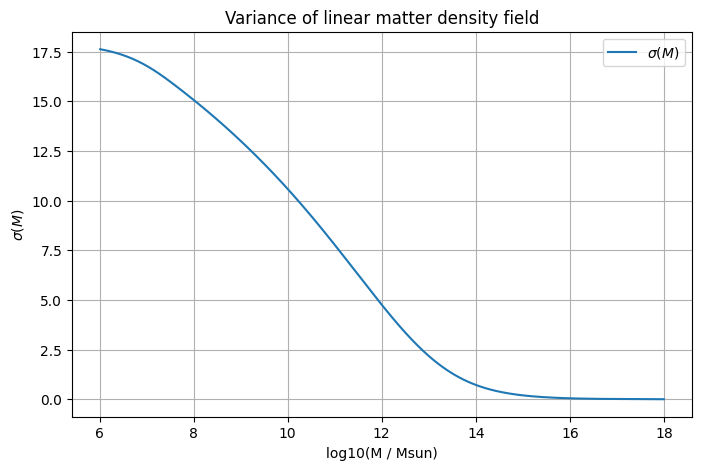

In [ ]:
# 8. Plot de halo mass function σ(M) vs mass
plt.figure(figsize=(8,5))
plt.plot(sigma_cache.km, sigma_cache.sg, label=r"$\sigma(M)$")
plt.xlabel("log10(M / Msun)")
plt.ylabel(r"$\sigma(M)$")
plt.title("Variance of linear matter density field")
plt.legend()
plt.grid(True)
plt.show()


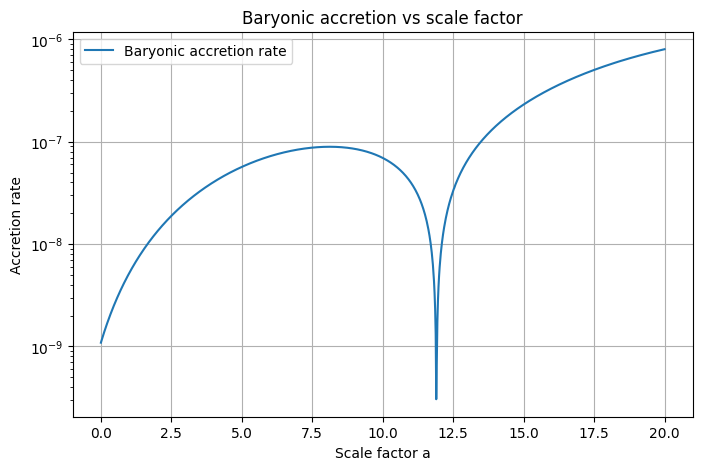

In [ ]:
# 9. Plot de baryonic accretion vs scale factor
plt.figure(figsize=(8,5))
plt.plot(1/halo_accretion.ascale-1, halo_accretion.abt2, label="Baryonic accretion rate")
plt.xlabel("Scale factor a")
plt.ylabel("Accretion rate")
plt.title("Baryonic accretion vs scale factor")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()